In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
import os


In [ ]:
# Set random seed for reproducibility
seed = 3
np.random.seed(seed) 

In [3]:
# Working directory + Project folder
working_directory = os.getcwd()
project_folder = os.path.dirname(working_directory)

# Data folder
data_folder = os.path.join(project_folder, "data")
os.makedirs(data_folder, exist_ok=True)

# Visuals folder
visuals_folder = os.path.join(project_folder, "visuals")
os.makedirs(visuals_folder, exist_ok=True)

# Output folder
output_folder = os.path.join(project_folder, "output")
os.makedirs(output_folder, exist_ok=True)

In [4]:
# loading data 
facilitiesfile = os.path.join(data_folder, 'assisted-living-facilities.csv')
df = pd.read_csv(facilitiesfile, sep=',')
populationfile = os.path.join(data_folder, 'DECENNIALDP2020.DP1-2025-08-21T181057.csv')
df_pop = pd.read_csv(populationfile, sep=',')

In [5]:
df.head()

,Facility ID,Facility Name,Address,City,State,Zip Code,Phone Number,County,Licensee,State Facility Type 2 Literal,...,County Percent Black Population,County Median Home Value of Owned Homes,County Percent Hispanic Population,County Percent of Population 85 or Older,County Median Household Income,County Unemployment Rate,County Less Than High School Diploma Rate,County Percent Whilte Population,County Gender Ratio,County Poverty Rate
0,NaN,American House Keene,197 WATER ST,Keene,NH,3431,(603) 352-1282,Cheshire,NaN,RESIDENTIAL CARE FACILITY,...,0.90,195300.0,1.85,2.58,64751.0,6.1,6.64,95.15,95.0,8.98
1,NaN,Artaban House,40 PLOWSHARE LANE,Greenfield,NH,3047,(603) 547-3717,Hillsborough,NaN,RESIDENTIAL CARE FACILITY,...,2.91,274800.0,6.77,1.86,81460.0,7.0,7.89,89.43,99.0,7.77
2,NaN,Assisted Living At Pine Hill,35 NORTH LOWELL RD,Windham,NH,3087,(603) 506-6626,Rockingham,NaN,RESIDENTIAL CARE FACILITY,...,0.83,326300.0,2.99,1.89,93756.0,7.1,4.87,94.72,98.0,4.64
3,NaN,Austin Home,532 WHITE PLAINS ROAD,Webster,NH,3303,(603) 456-3525,Merrimack,NaN,RESIDENTIAL CARE FACILITY,...,1.43,237600.0,2.16,2.59,75737.0,5.8,6.75,94.06,97.0,6.53
4,NaN,Beaver Lake Lodge,38 NORTH SHORE ROAD,Derry,NH,3038,(603) 434-5683,Rockingham,NaN,RESIDENTIAL CARE FACILITY,...,0.83,326300.0,2.99,1.89,93756.0,7.1,4.87,94.72,98.0,4.64


In [6]:
df_pop.head()

,Label (Grouping),Minnesota!!Count,Minnesota!!Percent,"Aitkin County, Minnesota!!Count","Aitkin County, Minnesota!!Percent","Anoka County, Minnesota!!Count","Anoka County, Minnesota!!Percent","Becker County, Minnesota!!Count","Becker County, Minnesota!!Percent","Beltrami County, Minnesota!!Count",...,"Watonwan County, Minnesota!!Count","Watonwan County, Minnesota!!Percent","Wilkin County, Minnesota!!Count","Wilkin County, Minnesota!!Percent","Winona County, Minnesota!!Count","Winona County, Minnesota!!Percent","Wright County, Minnesota!!Count","Wright County, Minnesota!!Percent","Yellow Medicine County, Minnesota!!Count","Yellow Medicine County, Minnesota!!Percent"
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"5,706,494",100.0%,"15,697",100.0%,"363,887",100.0%,"35,183",100.0%,"46,228",...,"11,253",100.0%,"6,506",100.0%,"49,671",100.0%,"141,337",100.0%,"9,528",100.0%
2,Under 5 years,"340,357",6.0%,585,3.7%,"22,647",6.2%,"2,047",5.8%,"3,126",...,777,6.9%,395,6.1%,"2,385",4.8%,"9,548",6.8%,546,5.7%
3,5 to 9 years,"366,937",6.4%,668,4.3%,"24,168",6.6%,"2,407",6.8%,"3,180",...,818,7.3%,408,6.3%,"2,554",5.1%,"11,125",7.9%,601,6.3%
4,10 to 14 years,"383,116",6.7%,853,5.4%,"25,796",7.1%,"2,480",7.0%,"3,257",...,789,7.0%,463,7.1%,"2,758",5.6%,"12,172",8.6%,661,6.9%


In [7]:
# Limiting to first 21 rows
df_pop = df_pop.iloc[1:20]
display((df_pop[['Label (Grouping)']].T))
print("\n")

# Removing age ranges outside interest
df_pop = df_pop.drop(index=range(2, 15))
df_pop = df_pop.reset_index(drop=True)
display(df_pop[['Label (Grouping)']].T)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Label (Grouping),Total population,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,25 to 29 years,30 to 34 years,35 to 39 years,40 to 44 years,45 to 49 years,50 to 54 years,55 to 59 years,60 to 64 years,65 to 69 years,70 to 74 years,75 to 79 years,80 to 84 years,85 years and over


,0,1,2,3,4,5
Label (Grouping),Total population,65 to 69 years,70 to 74 years,75 to 79 years,80 to 84 years,85 years and over


In [8]:
# Cleaning of Population data
df_pop.rename(columns={'Minnesota!!Count': 'Population'}, inplace=True)

# Removing redundant columns
df_pop = df_pop.drop(columns=[col for col in df_pop.columns if 'Percent' in col])
df_pop.head()

# Removing 'County'
df_pop.columns = [col.split('County')[0] for col in df_pop.columns]
df_pop

,Label (Grouping),Population,Aitkin,Anoka,Becker,Beltrami,Benton,Big Stone,Blue Earth,Brown,...,Traverse,Wabasha,Wadena,Waseca,Washington,Watonwan,Wilkin,Winona,Wright,Yellow Medicine
0,Total population,"5,706,494","15,697","363,887","35,183","46,228","41,379","5,166","69,112","25,912",...,"3,360","21,387","14,065","18,968","267,568","11,253","6,506","49,671","141,337","9,528"
1,65 to 69 years,"315,161","1,522","18,256","2,587","2,666","2,018",403,"3,394","1,744",...,236,"1,502",949,"1,154","14,425",689,397,"3,044","6,314",665
2,70 to 74 years,"242,037","1,357","14,010","2,085","2,050","1,515",325,"2,570","1,342",...,181,"1,237",764,931,"11,357",484,295,"2,368","5,001",455
3,75 to 79 years,"164,798","1,076","9,386","1,431","1,339","1,042",236,"1,741","1,007",...,176,890,597,561,"7,442",391,211,"1,608","3,501",371
4,80 to 84 years,"110,639",702,"5,560",923,955,733,184,"1,234",764,...,123,603,432,394,"4,858",299,168,"1,086","2,149",259
5,85 years and over,"116,658",511,"4,824",823,934,857,249,"1,516",945,...,166,571,513,449,"4,797",361,220,"1,136","1,877",277


In [9]:
# Transposing columns to rows
df_popt = df_pop.T.reset_index()
df_popt[:5]

,index,0,1,2,3,4,5
0,Label (Grouping),Total population,65 to 69 years,70 to 74 years,75 to 79 years,80 to 84 years,85 years and over
1,Population,"5,706,494","315,161","242,037","164,798","110,639","116,658"
2,Aitkin,"15,697","1,522","1,357","1,076",702,511
3,Anoka,"363,887","18,256","14,010","9,386","5,560","4,824"
4,Becker,"35,183","2,587","2,085","1,431",923,823


In [10]:
# Column names defined by first row
df_popt.columns = df_popt.iloc[0]
df_popt = df_popt.drop(df_popt.index[0])

# Renaming 'Label' as County
df_popt = df_popt.rename(columns={df_popt.columns[0]: 'County'})

#Removing whitespaces
df_popt.columns = df_popt.columns.str.strip()
df_popt['County'] = df_popt['County'].str.strip()


# Removing commas and converting to integers
for col in df_popt.columns[1:]:
    df_popt[col] = df_popt[col].str.replace(',', '').astype(int)

# Creating 'Population 65 years and over' colum
df_popt['Population 65 years and over'] = df_popt[['65 to 69 years', '70 to 74 years',
                                        '75 to 79 years', '80 to 84 years', '85 years and over']].sum(axis=1)

# Renaming
df_popt.rename(columns={'Total population': 'Total Population',
                        '85 years and over': 'Population 85 years and over'}, inplace=True)

# Dropping columns
df_popt.drop(columns=['65 to 69 years', '70 to 74 years', '75 to 79 years', '80 to 84 years'], inplace=True)

# Removing Total Population from Counties
df_popt = df_popt[df_popt['County'] != 'Population'].reset_index(drop=True)
df_popt[:5]

,County,Total Population,Population 85 years and over,Population 65 years and over
0,Aitkin,15697,511,5168
1,Anoka,363887,4824,52036
2,Becker,35183,823,7849
3,Beltrami,46228,934,7944
4,Benton,41379,857,6165


In [11]:
# Removing whitespaces
df.columns = df.columns.str.strip()

# Filtering to Minnesota
df = df[df['State'].str.upper() == 'MN']

# Removing whitespaces in each County
df['County'] = df['County'].str.strip()

# Removing 'County ' from columns that are not the 'County' column)
df.columns = [
    col.replace('County ', '') if col.startswith('County ') and col != 'County' else col
    for col in df.columns]

In [12]:
# Merging df and df_popt
df_merged = df.merge(df_popt, on='County', how='left')
df = df_merged.copy()
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City', 'State', 'Zip Code',
       'Phone Number', 'County', 'Licensee', 'State Facility Type 2 Literal',
       'State Facility Type 1 Literal', 'Date Accessed', 'License Number',
       'Capacity', 'Email Address', 'Ownership Type', 'Latitude', 'Longitude',
       'FIPS', 'Total County AL Need', 'Percent of Population 65 or Older',
       'Median Age', 'Homeownership Rate', 'College Education or Higher Rate',
       'Percent Black Population', 'Median Home Value of Owned Homes',
       'Percent Hispanic Population', 'Percent of Population 85 or Older',
       'Median Household Income', 'Unemployment Rate',
       'Less Than High School Diploma Rate', 'Percent Whilte Population',
       'Gender Ratio', 'Poverty Rate', 'Total Population',
       'Population 85 years and over', 'Population 65 years and over'],
      dtype='object')

In [13]:
# Filtering to Counties with a Total Population > 20,000
df = df[df['Total Population'] > 20000]

In [14]:
# Combining ages 65 + 85 populations
pop65_and_85 = df.groupby('County').agg({
    'Total Population': 'first',
    'Population 65 years and over': 'first',
    'Population 85 years and over': 'first'
}).reset_index()

pop_elderly = pop65_and_85[['County', 'Population 65 years and over', 'Population 85 years and over']]
pop_elderly['Elderly'] = pop65_and_85['Population 65 years and over'] + pop65_and_85['Population 85 years and over']
pop_elderly.drop(columns=['Population 65 years and over', 'Population 85 years and over'], inplace=True)
pop_elderly[:5]

,County,Elderly
0,Anoka,56860.0
1,Becker,8672.0
2,Beltrami,8878.0
3,Benton,7022.0
4,Blue Earth,11971.0


In [15]:
# Sum facilities per county
sumfacilities = df.groupby('County')['Facility Name'].count()
sumfacilities = sumfacilities.rename('Facilities')

# Merging on County
county_summary = pop_elderly.set_index('County').join(sumfacilities)
county_summary['Facilities per 1000 Elderly'] = (county_summary['Facilities'] / county_summary['Elderly']) * 1000
county_summary = county_summary.reset_index()
county_summary = county_summary[['County', 'Facilities', 'Elderly', 'Facilities per 1000 Elderly']]

In [16]:
# Categorizing Facility Saturation
county_summary = county_summary[county_summary['Facilities'] > 0].copy()
county_summary['Elderly'] = pd.to_numeric(county_summary['Elderly'], errors='coerce').fillna(0)
county_summary['Facilities per 1000 Elderly'] = pd.to_numeric(county_summary['Facilities per 1000 Elderly'],
                                                              errors='coerce').fillna(0)

labels = ['Low', 'Medium', 'High']
county_summary['Facility Saturation'] = pd.cut(county_summary['Facilities per 1000 Elderly'],
                                               bins=3, labels=labels)
county_summary[:5]

,County,Facilities,Elderly,Facilities per 1000 Elderly,Facility Saturation
0,Anoka,134,56860.0,2.356665,Medium
1,Becker,15,8672.0,1.729705,Low
2,Beltrami,15,8878.0,1.689570,Low
3,Benton,15,7022.0,2.136144,Medium
4,Blue Earth,19,11971.0,1.587169,Low


In [17]:
# Analysis Variables
county_variables = df.groupby('County')[['Total Population', 'Poverty Rate', 'Unemployment Rate',
                                        'Median Household Income', 'Median Home Value of Owned Homes',
                                        'Less Than High School Diploma Rate', 'College Education or Higher Rate',
                                         'Median Age']].first().reset_index()

county_variables = county_variables.merge(county_summary, on='County')
display(county_variables[:5])

X = county_variables[['Elderly', 'Total Population', 'Poverty Rate', 'Unemployment Rate', 'Median Household Income',
                     'Median Home Value of Owned Homes', 'Less Than High School Diploma Rate',
                     'College Education or Higher Rate', 'Median Age']]
y = county_variables['Facility Saturation']

,County,Total Population,Poverty Rate,Unemployment Rate,Median Household Income,Median Home Value of Owned Homes,Less Than High School Diploma Rate,College Education or Higher Rate,Median Age,Facilities,Elderly,Facilities per 1000 Elderly,Facility Saturation
0,Anoka,363887.0,5.89,6.3,82175.0,232400.0,6.02,30.51,39.0,134,56860.0,2.356665,Medium
1,Becker,35183.0,11.00,6.2,60284.0,198400.0,6.86,24.97,42.0,15,8672.0,1.729705,Low
2,Beltrami,46228.0,18.89,6.3,49160.0,162600.0,7.87,29.22,34.0,15,8878.0,1.689570,Low
3,Benton,41379.0,10.32,6.6,57715.0,174900.0,8.29,23.57,36.0,15,7022.0,2.136144,Medium
4,Blue Earth,69112.0,17.61,5.4,57429.0,184800.0,5.47,34.82,31.0,19,11971.0,1.587169,Low


In [18]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Random Forest Classifier
rf = RandomForestClassifier(class_weight="balanced", random_state=seed)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

Accuracy: 80.0 %
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.80      1.00      0.89         8
      Medium       0.00      0.00      0.00         1

    accuracy                           0.80        10
   macro avg       0.27      0.33      0.30        10
weighted avg       0.64      0.80      0.71        10



In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(RandomForestClassifier(), param_grid, random_state=seed)

random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)

rs_pred = random_search.predict(X_test)
print(classification_report(y_test, rs_pred))
print(accuracy_score(y_test, rs_pred) * 100, "%")

best_rf = random_search.best_estimator_

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Best Estimator: RandomForestClassifier(bootstrap=False, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200)
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.89      1.00      0.94         8
      Medium       1.00      1.00      1.00         1

    accuracy                           0.90        10
   macro avg       0.63      0.67      0.65        10
weighted avg       0.81      0.90      0.85        10

90.0 %


In [20]:
# Feature importances
feature_importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_df

,Feature,Importance
0,Total Population,0.178699
1,Median Home Value of Owned Homes,0.163713
2,Less Than High School Diploma Rate,0.138352
3,Elderly,0.132917
4,Poverty Rate,0.128662
5,College Education or Higher Rate,0.092876
6,Unemployment Rate,0.077712
7,Median Age,0.049167
8,Median Household Income,0.037902


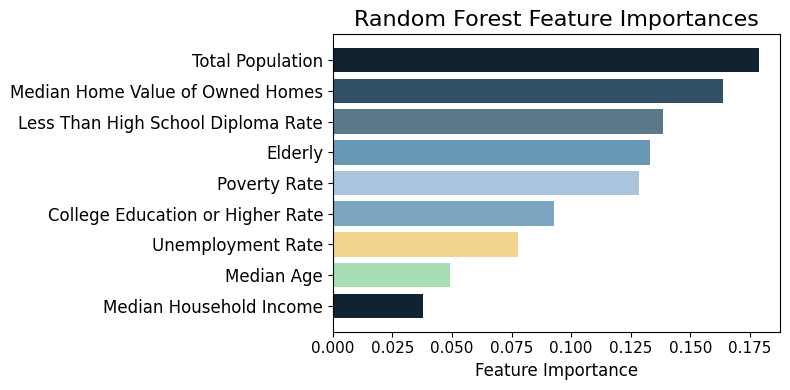

In [21]:
# Plotting feature importances
colors = ['#112231', '#315066', '#5b7888', '#6998b4', '#aac4de', '#7ca6c0', '#f3d58e', '#a9ddb6']

plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Random Forest Feature Importances", fontsize=16)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()

# Saving feature importance plot
feature_importance_path = os.path.join(visuals_folder, "random_forest_feature_importance.png")
plt.savefig(feature_importance_path)

plt.show()

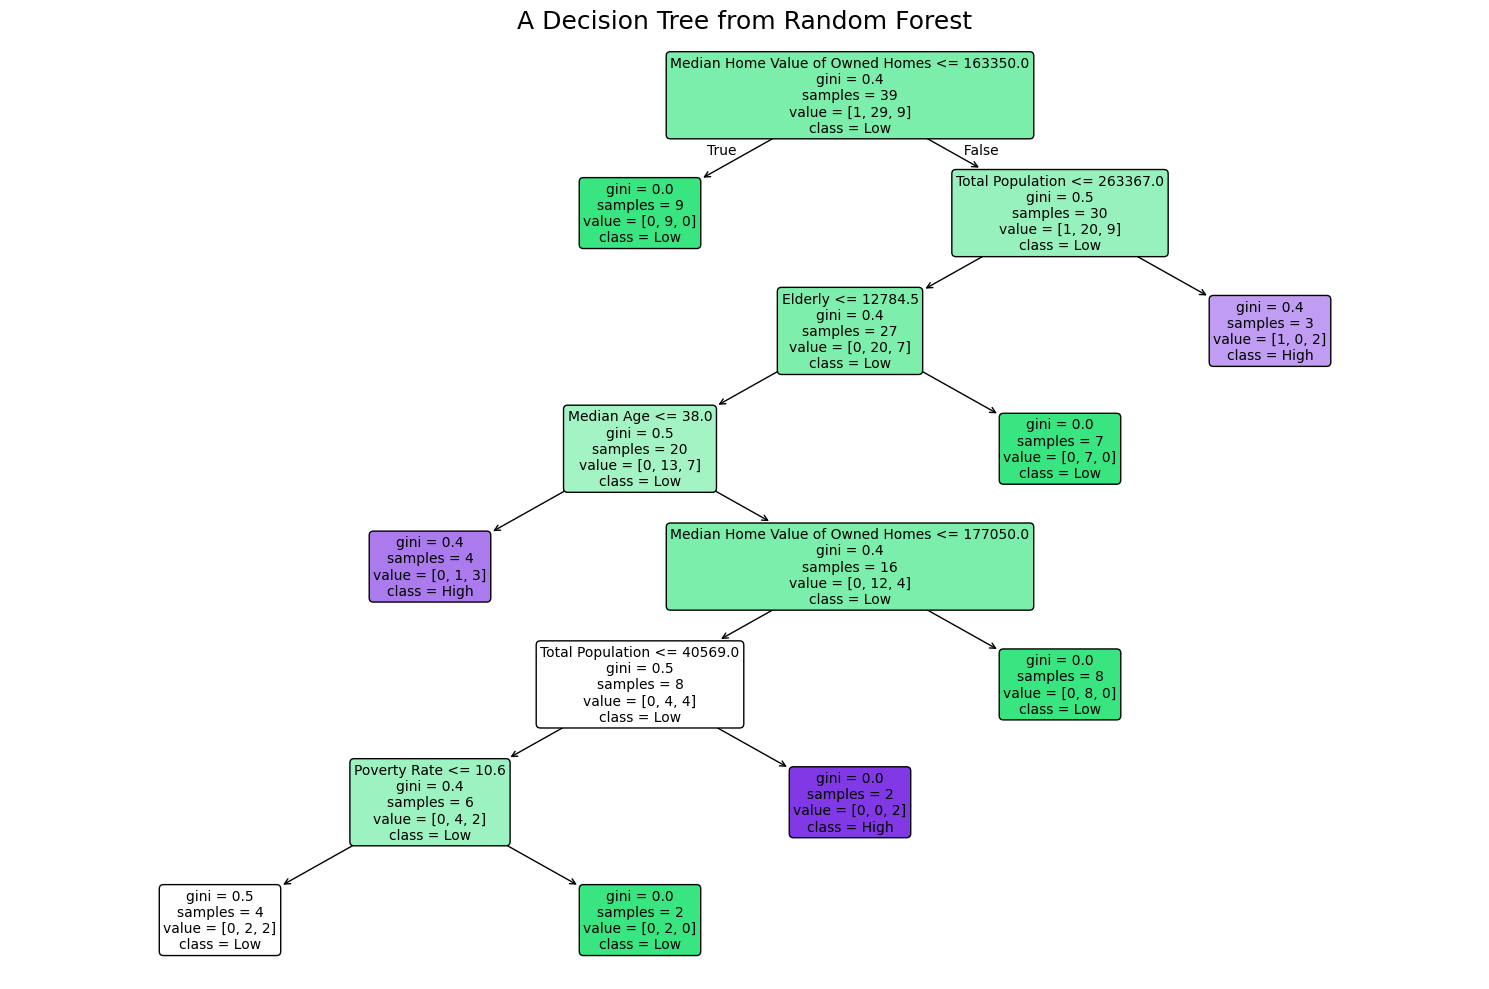

In [22]:
# decision tree
individual_tree = best_rf.estimators_[seed]

# plot_tree
plt.figure(figsize=(15, 10))
plot_tree(individual_tree, feature_names=X_train.columns,
          class_names=y.unique().tolist(), filled=True,
          fontsize=10, rounded=True, precision=1)
plt.title("A Decision Tree from Random Forest", fontsize=18)
plt.tight_layout()

# saving feature importance plot
decision_tree_path = os.path.join(visuals_folder, "decision_tree_random_forest.png")
plt.savefig(decision_tree_path)

plt.show()

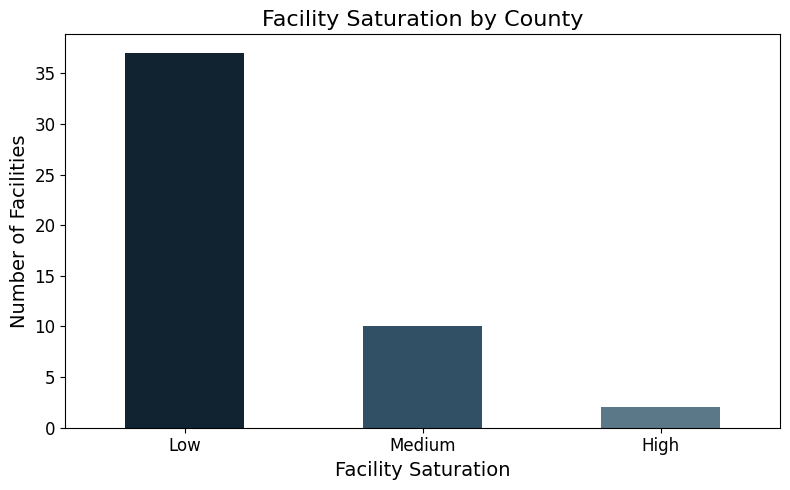

In [23]:
# Facility Saturation Bar Plot
county_summary['Facility Saturation'].value_counts().plot(kind='bar', color=colors, figsize=(8, 5))

plt.title("Facility Saturation by County",  fontsize=16)
plt.ylabel("Number of Facilities",  fontsize=14)
plt.xlabel("Facility Saturation",  fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# saving facility saturation plot
facility_saturation_path = os.path.join(visuals_folder, "facility_saturation_by_county.png")
plt.savefig(facility_saturation_path)

plt.show()

In [24]:
# to csv
county_variables.to_csv(os.path.join(output_folder, 'county_variables.csv'), index=False)
df.to_csv(os.path.join(output_folder, 'df.csv'), index=False)